# Battery Cell QC

I want to see if a battery's first few cycles can tell us whether it will wear out early.
If that works, a factory could catch weak cells before shipping them.

Data: NASA battery aging dataset. A battery counts as worn out at 1.4 Ah (it starts around 2 Ah).

## Loading the data

The dataset has charge, discharge and impedance tests. I only need discharge,
because that's where capacity is measured. I also number the cycles for each battery.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

meta = pd.read_csv("../data/cleaned_dataset/metadata.csv")
dis = meta[meta["type"] == "discharge"].copy()
dis["Capacity"] = pd.to_numeric(dis["Capacity"], errors="coerce")
dis["cycle"] = dis.groupby("battery_id").cumcount() + 1
dis.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,cycle
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.674305,NaN,NaN,1
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.524366,NaN,NaN,2
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.508076,NaN,NaN,3
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.483558,NaN,NaN,4
10,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.467139,NaN,NaN,5


## How capacity drops over time

Plotting capacity for four batteries. The red line is where a battery is considered worn out.

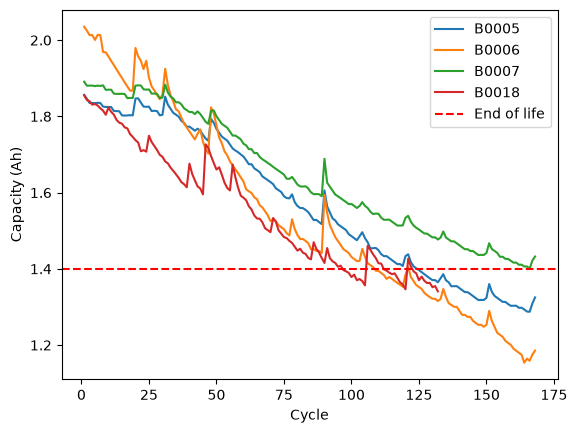

In [22]:
import os
os.makedirs("../images", exist_ok=True)   # creates the folder if it's missing

for b in ["B0005", "B0006", "B0007", "B0018"]:
    d = dis[dis["battery_id"] == b]
    plt.plot(d["cycle"], d["Capacity"], label=b)
plt.axhline(1.4, color="red", linestyle="--", label="End of life")
plt.xlabel("Cycle"); plt.ylabel("Capacity (Ah)"); plt.legend()
plt.savefig("../images/capacity_fade.png", dpi=150, bbox_inches="tight")
plt.show()

Some things I noticed:

- B0018 wears out first, around cycle 97. B0007 lasts the longest.
- B0006 starts with the most capacity but still fails early. So checking a battery
  only once when it's new wouldn't be enough.
- The sudden jumps happen at the same cycles for every battery. I think these are from
  rest breaks during testing, not the battery actually getting better.

## Looking at single discharges

Comparing B0005 at cycles 1, 50, 100 and 150. I want to see if the voltage drops
faster as the battery gets older.

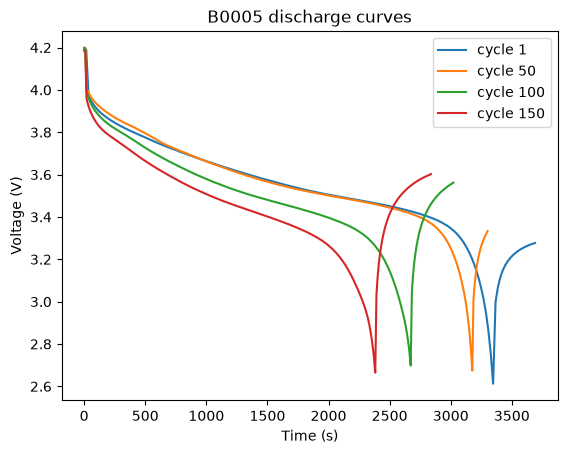

In [9]:
b5 = dis[dis["battery_id"] == "B0005"]

for c in [1, 50, 100, 150]:
    row = b5[b5["cycle"] == c].iloc[0]
    curve = pd.read_csv(f"../data/cleaned_dataset/data/{row['filename']}")
    plt.plot(curve["Time"], curve["Voltage_measured"], label=f"cycle {c}")

plt.xlabel("Time (s)"); plt.ylabel("Voltage (V)"); plt.title("B0005 discharge curves")
plt.legend(); plt.show()

Older cycles end sooner, and the voltage drops faster near the end.
So the length of a discharge and the shape of the curve should tell us about battery health.

## Turning curves into numbers

A model can't read a whole curve, so for each discharge I pull out a few simple numbers:
- how long it lasted before the voltage fell to 2.7 V
- the average voltage
- the highest temperature, and when it happened

I stop at 2.7 V for every battery so they're compared the same way.

In [11]:
four = dis[dis["battery_id"].isin(["B0005", "B0006", "B0007", "B0018"])]
rows = []

for _, r in four.iterrows():
    c = pd.read_csv(f"../data/cleaned_dataset/data/{r['filename']}")
    below = c[c["Voltage_measured"] < 2.7]
    end = below["Time"].iloc[0] if len(below) else c["Time"].iloc[-1]
    part = c[c["Time"] <= end]

    rows.append({
        "battery_id": r["battery_id"],
        "cycle": r["cycle"],
        "capacity": r["Capacity"],
        "discharge_time": end,
        "avg_voltage": part["Voltage_measured"].mean(),
        "max_temp": part["Temperature_measured"].max(),
        "time_to_max_temp": part.loc[part["Temperature_measured"].idxmax(), "Time"],
    })

feat = pd.DataFrame(rows)
feat.head()

,battery_id,cycle,capacity,discharge_time,avg_voltage,max_temp,time_to_max_temp
0,B0006,1,2.035338,3669.875,3.562462,38.891274,3669.875
1,B0006,2,2.025140,3651.875,3.567681,38.932566,3651.875
2,B0006,3,2.013326,3631.203,3.572558,38.749935,3631.203
3,B0006,4,2.013285,3631.563,3.568795,38.843628,3631.563
4,B0006,5,2.000528,3608.766,3.570622,38.643184,3608.766


## Do these numbers follow capacity?

Before building a model, I check how closely each feature moves with capacity.
Close to 1 or -1 means strongly related, close to 0 means not useful.

max_temp           -0.553266
avg_voltage         0.884079
time_to_max_temp    0.999243
discharge_time      0.999283
capacity            1.000000
Name: capacity, dtype: float64


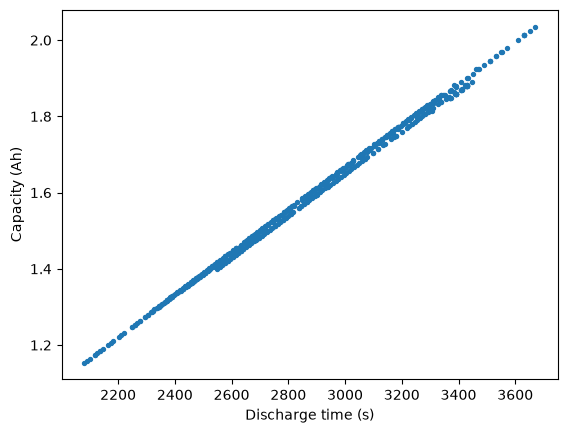

In [12]:
print(feat.drop(columns=["battery_id", "cycle"]).corr()["capacity"].sort_values())

plt.scatter(feat["discharge_time"], feat["capacity"], s=8)
plt.xlabel("Discharge time (s)"); plt.ylabel("Capacity (Ah)"); plt.show()

Discharge time matches capacity almost perfectly. That makes sense, since the current
is fixed at 2 A, so capacity is basically current × time.
Average voltage and the temperature peak timing also track capacity well.

## Training a model

Now I use those numbers to predict capacity. To test it fairly, I train on three batteries
and test on the fourth, then repeat so each battery gets a turn as the test one.
This way the model is always tested on a battery it has never seen.

In [13]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import mean_squared_error

X = feat[["discharge_time", "avg_voltage", "max_temp", "time_to_max_temp"]]
y = feat["capacity"]
groups = feat["battery_id"]

model = RandomForestRegressor(n_estimators=300, random_state=42)
feat["pred"] = cross_val_predict(model, X, y, groups=groups, cv=LeaveOneGroupOut())

print("Overall RMSE:", round(np.sqrt(mean_squared_error(y, feat["pred"])), 4), "Ah")
for b, g in feat.groupby("battery_id"):
    print(b, round(np.sqrt(mean_squared_error(g["capacity"], g["pred"])), 4))

Overall RMSE: 0.0261 Ah
B0005 0.0098
B0006 0.0463
B0007 0.0175
B0018 0.0061


## What if I split the data randomly?

Most tutorials split rows randomly. I tried it to compare.
Cycles next to each other are almost identical, so the model sees near-copies of the test data during training.

In [14]:
from sklearn.model_selection import KFold

pred_random = cross_val_predict(model, X, y, cv=KFold(5, shuffle=True, random_state=42))
print("Random split RMSE:", round(np.sqrt(mean_squared_error(y, pred_random)), 4), "Ah")

Random split RMSE: 0.0066 Ah


Random split: 0.0066 Ah. Battery-by-battery: 0.026 Ah.
The random split looks 4x better, but only because the model saw near-copies of the test cycles.

The random split looks better, but it's misleading. In a factory the model always sees
new batteries, so the battery-by-battery test is the honest number.

## Can the first 20 cycles catch a weak battery?

For each battery I take only the first 20 predicted capacities, draw a trend line,
and estimate when it will hit 1.4 Ah. If that's before cycle 120, I flag it HOLD.
Then I compare with when it really wore out.

In [15]:
spec = 120
for b, g in feat.groupby("battery_id"):
    early = g[g["cycle"] <= 20]
    slope, intercept = np.polyfit(early["cycle"], early["pred"], 1)
    projected = (1.4 - intercept) / slope if slope < 0 else np.inf

    below = g[g["capacity"] < 1.4]
    actual = int(below["cycle"].iloc[0]) if len(below) else "never"
    flag = "HOLD" if projected < spec else "PASS"
    print(f"{b}: projected {projected:.0f}, actual {actual}, flag {flag}")

B0005: projected 243, actual 125, flag PASS
B0006: projected 391, actual 109, flag PASS
B0007: projected 268, actual never, flag PASS
B0018: projected 94, actual 97, flag HOLD


## Can the first 30 cycles catch a weak battery?

For each battery I take only the first 20 predicted capacities, draw a trend line,
and estimate when it will hit 1.4 Ah. If that's before cycle 120, I flag it HOLD.
Then I compare with when it really wore out.

In [16]:
spec = 120
for b, g in feat.groupby("battery_id"):
    early = g[g["cycle"] <= 30]
    slope, intercept = np.polyfit(early["cycle"], early["pred"], 1)
    projected = (1.4 - intercept) / slope if slope < 0 else np.inf

    below = g[g["capacity"] < 1.4]
    actual = int(below["cycle"].iloc[0]) if len(below) else "never"
    flag = "HOLD" if projected < spec else "PASS"
    print(f"{b}: projected {projected:.0f}, actual {actual}, flag {flag}")

B0005: projected 535, actual 125, flag PASS
B0006: projected 421, actual 109, flag PASS
B0007: projected 581, actual never, flag PASS
B0018: projected 89, actual 97, flag HOLD


## Can the first 40 cycles catch a weak battery?

For each battery I take only the first 20 predicted capacities, draw a trend line,
and estimate when it will hit 1.4 Ah. If that's before cycle 120, I flag it HOLD.
Then I compare with when it really wore out.

In [17]:
spec = 120
for b, g in feat.groupby("battery_id"):
    early = g[g["cycle"] <= 40]
    slope, intercept = np.polyfit(early["cycle"], early["pred"], 1)
    projected = (1.4 - intercept) / slope if slope < 0 else np.inf

    below = g[g["capacity"] < 1.4]
    actual = int(below["cycle"].iloc[0]) if len(below) else "never"
    flag = "HOLD" if projected < spec else "PASS"
    print(f"{b}: projected {projected:.0f}, actual {actual}, flag {flag}")

B0005: projected 401, actual 125, flag PASS
B0006: projected 198, actual 109, flag PASS
B0007: projected 361, actual never, flag PASS
B0018: projected 80, actual 97, flag HOLD


Only B0018 got flagged. B0006 was missed every time.

B0006 starts at 2.04 Ah, but the other batteries never go above 1.89 Ah.
A random forest can't predict higher than what it has seen, so it squashed B0006's early values
and the fade looked flat.

Using 30 cycles made it worse, because of the recovery spike around cycle 30.

## What is the model paying attention to?

I use SHAP to see which numbers matter most to the model's predictions.

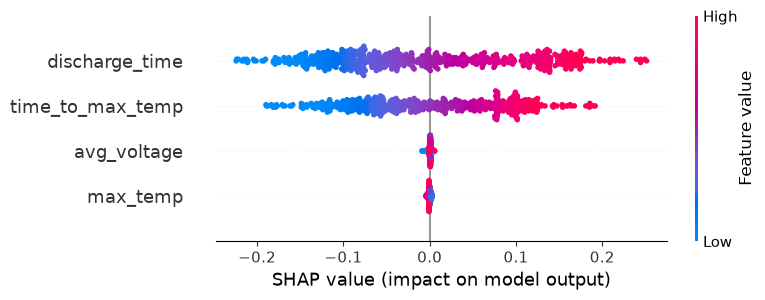

In [23]:
import shap

model.fit(X, y)
shap_values = shap.TreeExplainer(model).shap_values(X)
shap.summary_plot(shap_values, X, show=False)
plt.savefig("../images/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
X2 = feat[["avg_voltage", "max_temp"]]
pred2 = cross_val_predict(model, X2, y, groups=groups, cv=LeaveOneGroupOut())
print("RMSE without time features:", round(np.sqrt(mean_squared_error(y, pred2)), 4))

RMSE without time features: 0.1237


Discharge time matters most. Longer discharges mean more capacity, which makes sense.
Time to peak temperature says almost the same thing, since the temperature peaks near the end.
Average voltage and max temperature barely matter.

One catch: the current is fixed at 2 A, so capacity is roughly current × time.
The model is partly reading the answer straight from discharge time.

## Fix: use measured capacity instead of the prediction

In [20]:
spec = 120
for b, g in feat.groupby("battery_id"):
    early = g[g["cycle"] <= 20]
    slope, intercept = np.polyfit(early["cycle"], early["capacity"], 1)
    projected = (1.4 - intercept) / slope if slope < 0 else np.inf

    below = g[g["capacity"] < 1.4]
    actual = int(below["cycle"].iloc[0]) if len(below) else "never"
    flag = "HOLD" if projected < spec else "PASS"
    print(f"{b}: projected {projected:.0f}, actual {actual}, flag {flag}")

B0005: projected 217, actual 125, flag PASS
B0006: projected 78, actual 109, flag HOLD
B0007: projected 275, actual never, flag PASS
B0018: projected 82, actual 97, flag HOLD


Using the measured capacity from the first 20 cycles instead of the model's prediction,
all four batteries get the right flag. A factory measures capacity in early cycles anyway,
so this is realistic.

With only 4 batteries this is a small test, not proof. The next step would be checking it on more batteries.

## Results

| What | Result |
|---|---|
| Capacity error (tested on unseen batteries) | 0.026 Ah |
| Capacity error (random split, misleading) | 0.0066 Ah |
| Error without time features | 0.124 Ah |
| QC flag, first 20 cycles of measured capacity | 4 out of 4 correct |

**What worked:** the first 20 cycles were enough to spot both weak batteries (B0006, B0018),
including B0006, which started with the highest capacity.

**What didn't:** using the model's predicted capacity for the QC check missed B0006.
It started higher than any battery the model trained on, and a random forest can't predict above that.

**Limits:** only 4 batteries, all tested at room temperature. The next step is trying this on the
other NASA batteries to see if it still holds.